In [244]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [245]:
import pandas as pd
import numpy as np
import globals
from pathlib import Path
import matplotlib.pyplot as plt

In [246]:
filepath = Path("/Users/benny/Documents/swc/trait_analyses/trait_dataframes/df1.csv")
trait_df = pd.read_csv(filepath, index_col=0)

In [263]:
# binarising shift class based on whether a social shift happened or not regardless of second solo behaviour
for pseudo in trait_df.index:
    if trait_df.loc[pseudo,'shift_class']=='NO ADAPT' or trait_df.loc[pseudo,'shift_class']=='SHIFT POST SOCIAL':
        trait_df.loc[pseudo,'binary_shift_class']='NO SHIFT'
    else:
        trait_df.loc[pseudo,'binary_shift_class']='SHIFT'

## Pie chart for adaptation categories

In [265]:
from pypalettes import load_cmap
from pypalettes import load_palette
cmap = load_cmap("excel_Slipstream")
colors = load_palette("excel_Slipstream")
label_colors = colors

([<matplotlib.patches.Wedge at 0x17506e990>,
 [Text(0.48819049467746223, 1.008002996476982, 'NO ADAPT'),
  Text(-1.1198645479025562, -0.017418218938906615, 'SUSTAINED'),
  Text(-0.2078135028601254, -1.1005514745022174, 'ADAPT & REVERSE'),
  Text(0.5499132269732316, -0.9757025380718691, 'CONT SHFIT'),
  Text(1.029675383170745, -0.4406456686411201, 'SHIFT POST SOCIAL')],
 [Text(0.3051190591734138, 0.6300018727981138, '35.6%'),
  Text(-0.6999153424390975, -0.010886386836816633, '29.2%'),
  Text(-0.12988343928757837, -0.6878446715638857, '14.4%'),
  Text(0.3436957668582697, -0.6098140862949182, '7.9%'),
  Text(0.6435471144817155, -0.2754035429007, '12.9%')])

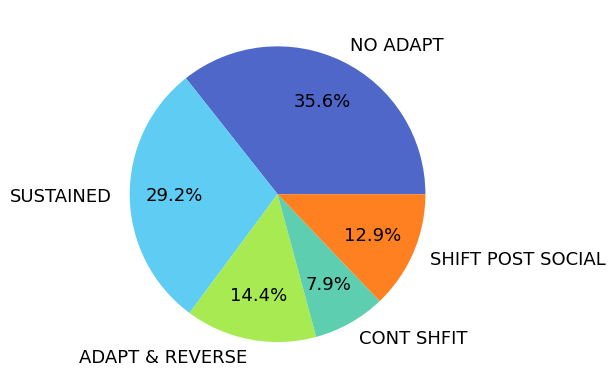

In [270]:
# fractions of different adaptation categories
shift_class = trait_df['shift_class'].tolist()

from collections import Counter
items = list(Counter(shift_class).keys())
counts = list(Counter(shift_class).values())

df = pd.DataFrame(
    {"counts": [72, 59, 29, 16, 26]},
    index=["NO ADAPT", "SUSTAINED", "ADAPT & REVERSE", "CONT SHFIT", "SHIFT POST SOCIAL"],
)

fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

([<matplotlib.patches.Wedge at 0x1750e7c50>,
 [Text(0.052237196385437855, 1.1187811561309877, 'NO SHIFT'),
  Text(-0.05223696520937108, -1.1187811669248438, 'SHIFT')],
 [Text(0.03264824774089865, 0.6992382225818672, '48.5%'),
  Text(-0.03264810325585692, -0.6992382293280273, '51.5%')])

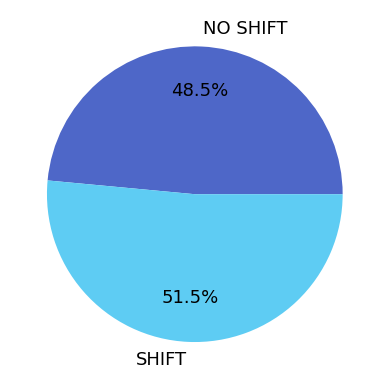

In [274]:
# fractions of different BINARY adaptation categories
binary_shift_class = trait_df['binary_shift_class'].tolist()

from collections import Counter
items = list(Counter(binary_shift_class).keys())
counts = list(Counter(binary_shift_class).values())

df = pd.DataFrame(
    {"counts": [98, 104]},
    index=['NO SHIFT', 'SHIFT'],
)

fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

## Confusion matrix for dyads

In [275]:
opponents = list(trait_df['opponent'])

In [276]:
shift_class_player = shift_class
binary_shift_class_player = binary_shift_class

In [277]:
shift_class_opponent = []
binary_shift_class_opponent = []
for i, opponent in enumerate(opponents):
    shift_class = trait_df['shift_class'][opponent]
    binary_shift_class =  trait_df['binary_shift_class'][opponent]
    shift_class_opponent.append(shift_class)
    binary_shift_class_opponent.append(binary_shift_class)

trait_df['shift_class_opponent'] = shift_class_opponent
trait_df['binary_shift_class_opponent'] = binary_shift_class_opponent

In [278]:
# Importing LabelEncoder from Sklearn 
# library from preprocessing Module.
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()

# Using .fit_transform function to fit label
# encoder and return encoded label
player_labels = le.fit_transform(shift_class_player)
opponent_labels = le.fit_transform(shift_class_opponent)

binary_player_labels = le.fit_transform(binary_shift_class_player)
binary_opponent_labels = le.fit_transform(binary_shift_class_opponent)

In [147]:
# confusion matrices

# 1. likelihood of pairings

In [279]:
# create list of player-opponent pairs
#dyads = list(zip(player_labels, opponent_labels))
dyads = list(zip(shift_class_player, shift_class_opponent))
bianry_dyads = list(zip(binary_shift_class_player, binary_shift_class_opponent))

count = Counter(dyads) # this creates a dict with items being the possible dyads and values being the frequency of appearance
binary_count = Counter(bianry_dyads)

sorted_counts = sorted(count.items(), key=lambda tup: (tup[0][1], tup[0][0]))
sorted_bianry_counts = sorted(binary_count.items(), key=lambda tup: (tup[0][1], tup[0][0]))

types_of_dyads = [dyad for dyad, freq in sorted_counts]
types_of_binary_dyads = [dyad for dyad, freq in sorted_bianry_counts]
frequency_of_dyads = [freq for dyad, freq in sorted_counts]
frequency_of_binary_dyads = [freq for dyad, freq in sorted_bianry_counts]

In [280]:
import seaborn as sns

In [281]:
cmap = load_cmap("Mint")

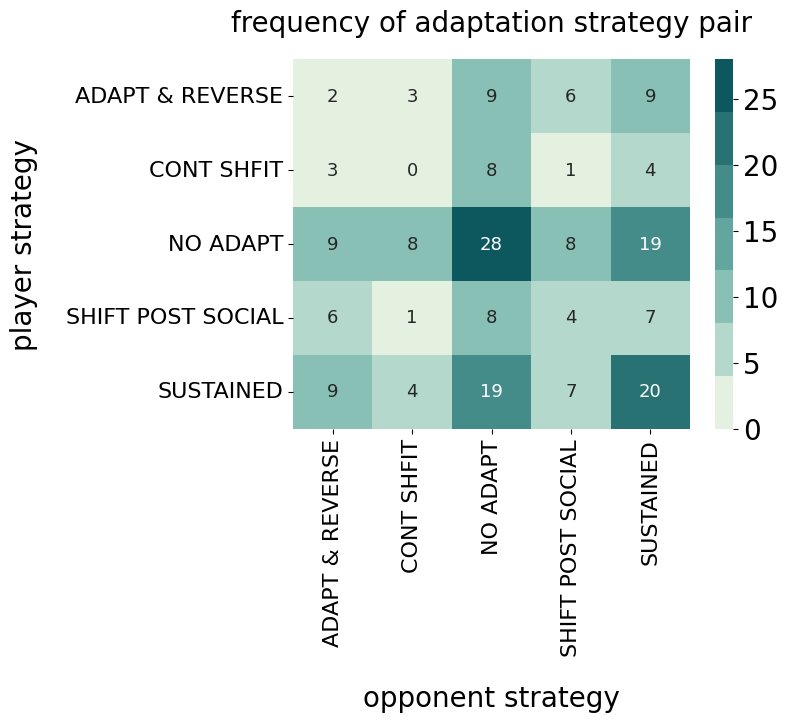

In [282]:
cm = pd.DataFrame(
    0,
    index=sorted(set(shift_class_player)),
    columns=sorted(set(shift_class_opponent))
)

for (player,opponent), freq in count.items():
    cm.loc[player, opponent] = freq

sns.heatmap(cm, annot=True, cmap=cmap, annot_kws={"size":13})

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("frequency of adaptation strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

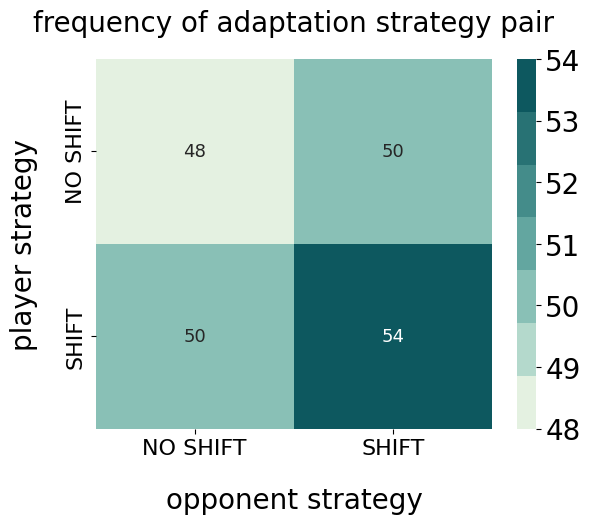

In [283]:
cm = pd.DataFrame(
    0,
    index=sorted(set(binary_shift_class_player)),
    columns=sorted(set(binary_shift_class_opponent))
)

for (player,opponent), freq in binary_count.items():
    cm.loc[player, opponent] = freq

sns.heatmap(cm, annot=True, cmap=cmap, annot_kws={"size":13})

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("frequency of adaptation strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

In [ ]:
# confusion matrices

# 2. proportion scores

In [284]:
proportion_scores = list(trait_df['proportion_score'])

In [195]:
heatmap_data = pd.pivot_table(
    trait_df,
    values='proportion_score',
    index='shift_class',
    columns='shift_class_opponent',
    aggfunc='mean'
)

In [285]:
heatmap_data = pd.pivot_table(
    trait_df,
    values='proportion_score',
    index='binary_shift_class',
    columns='binary_shift_class_opponent',
    aggfunc='mean'
)

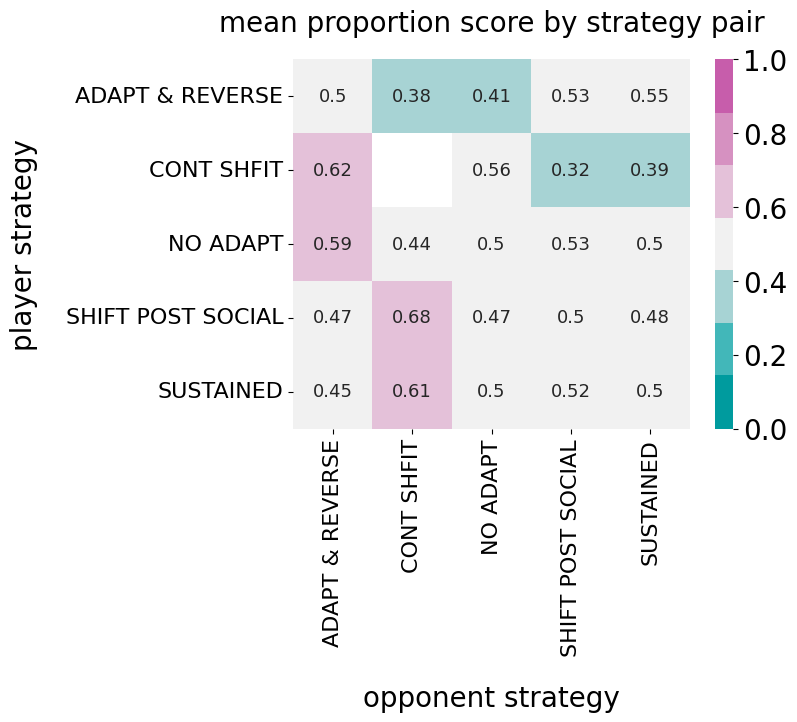

In [226]:
cmap = load_cmap("Tropic")

# cell values
# 0.5: equal performance
# 0.6 and above: row strategy typically gets 60+% of points against column strategy
# 0.4 and below: column strategy typically gets 60+% of points against column strategy

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1, 
    annot_kws={"size":13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean proportion score by strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

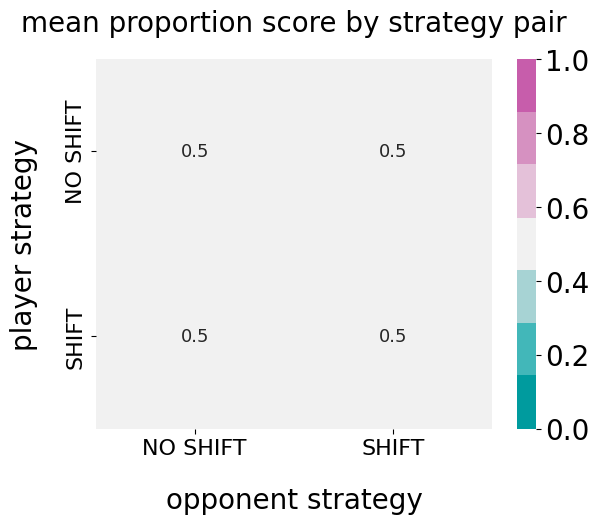

In [286]:
cmap = load_cmap("Tropic")

# cell values
# 0.5: equal performance
# 0.6 and above: row strategy typically gets 60+% of points against column strategy
# 0.4 and below: column strategy typically gets 60+% of points against column strategy

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1, 
    annot_kws={"size":13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean proportion score by strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

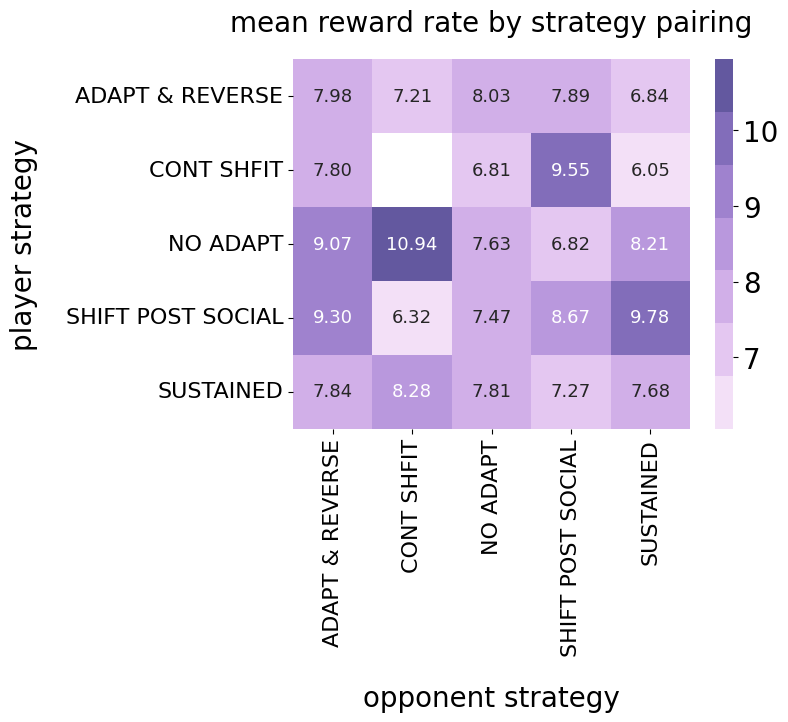

In [243]:
scores_per_second_matrix = pd.pivot_table(
    trait_df,
    values='scores_per_unit_time_socials',
    index='shift_class',
    columns='shift_class_opponent',
    aggfunc='mean'
)

cmap = load_cmap("Purp")

sns.heatmap(
    scores_per_second_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    annot_kws={"size": 13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean reward rate by strategy pairing", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

# cells: when row strategy meets column strategy, the former gets X points/s average

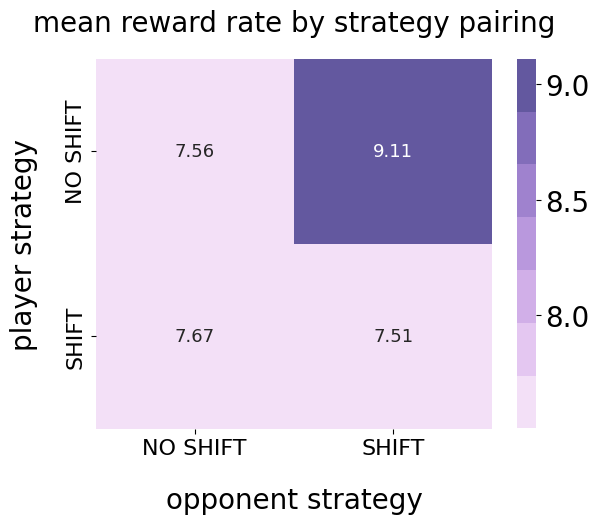

In [287]:
scores_per_second_matrix = pd.pivot_table(
    trait_df,
    values='scores_per_unit_time_socials',
    index='binary_shift_class',
    columns='binary_shift_class_opponent',
    aggfunc='mean'
)

cmap = load_cmap("Purp")

sns.heatmap(
    scores_per_second_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    annot_kws={"size": 13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean reward rate by strategy pairing", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

# cells: when row strategy meets column strategy, the former gets X points/s average

In [236]:
scores_per_second_matrix

shift_class_opponent,ADAPT & REVERSE,CONT SHFIT,NO ADAPT,SHIFT POST SOCIAL,SUSTAINED
shift_class,,,,,
ADAPT & REVERSE,7.980093,7.207113,8.026735,7.888855,6.835551
CONT SHFIT,7.798113,NaN,6.812637,9.553038,6.052571
NO ADAPT,9.072596,10.941075,7.633154,6.824511,8.207245
SHIFT POST SOCIAL,9.295613,6.324311,7.468276,8.669587,9.783451
SUSTAINED,7.841669,8.282751,7.806492,7.268790,7.678381


## Proactive/fast reactive vs slow reactive adaptation

### Change in centrality between final 20% of first solo to first 10-15% of social

In [289]:
occupancy_dict = pd.read_pickle('/Users/benny/Documents/swc/pickled_df/occupancy_dict.pkl') 

In [302]:
raw_social_centrality = occupancy_dict['socials']['raw_values']
raw_first_solo_centrality = occupancy_dict['first_solos']['raw_values']
raw_second_solo_centrality = occupancy_dict['second_solos']['raw_values']

In [356]:
occupancy_dict['first_solos']['final_20_pct'] = {}
occupancy_dict['socials']['first_10_pct'] = {}

occupancy_dict['first_solos']['final_20_pct']['values'] = {}
occupancy_dict['socials']['first_10_pct']['values'] = {}


occupancy_dict['first_solos']['final_20_pct']['mean'] = {}
occupancy_dict['socials']['first_10_pct']['mean'] = {}

In [360]:
for pseudo in trait_df.index:

    centralities_solo = raw_first_solo_centrality[pseudo]
    centralities_social = raw_social_centrality[pseudo]

    trial_length_solo = len(centralities_solo[0])
    trial_length_social = len(centralities_social)

    window_length_solo = int(trial_length_solo - np.round(trial_length_solo/5))
    window_length_social = int(trial_length_solo - np.round(trial_length_solo/10))

    final_20_pct = centralities_solo[0][window_length_solo:]
    first_10_pct = centralities_social[1:window_length_social]

    occupancy_dict['first_solos']['final_20_pct']['values'][pseudo] = final_20_pct
    occupancy_dict['socials']['first_10_pct']['values'][pseudo] = first_10_pct

    occupancy_dict['first_solos']['final_20_pct']['mean'][pseudo] = np.nanmean(final_20_pct)
    occupancy_dict['socials']['first_10_pct']['mean'][pseudo] = np.nanmean(first_10_pct)

In [350]:
import math

In [354]:
seen_pairs = set()
pseudo_tuples_list = []
for i in range(len(trait_df)):
    player = trait_df.index[i]
    opponent = trait_df['opponent'].iloc[i]
    pair = frozenset([player, opponent])
    if pair not in seen_pairs:
        pseudo_tuples_list.append([player, opponent])
        seen_pairs.add(pair)

In [369]:
n_plots = len(pseudo_tuples_list)
n_cols = 10
n_rows = math.ceil(n_plots / n_cols)

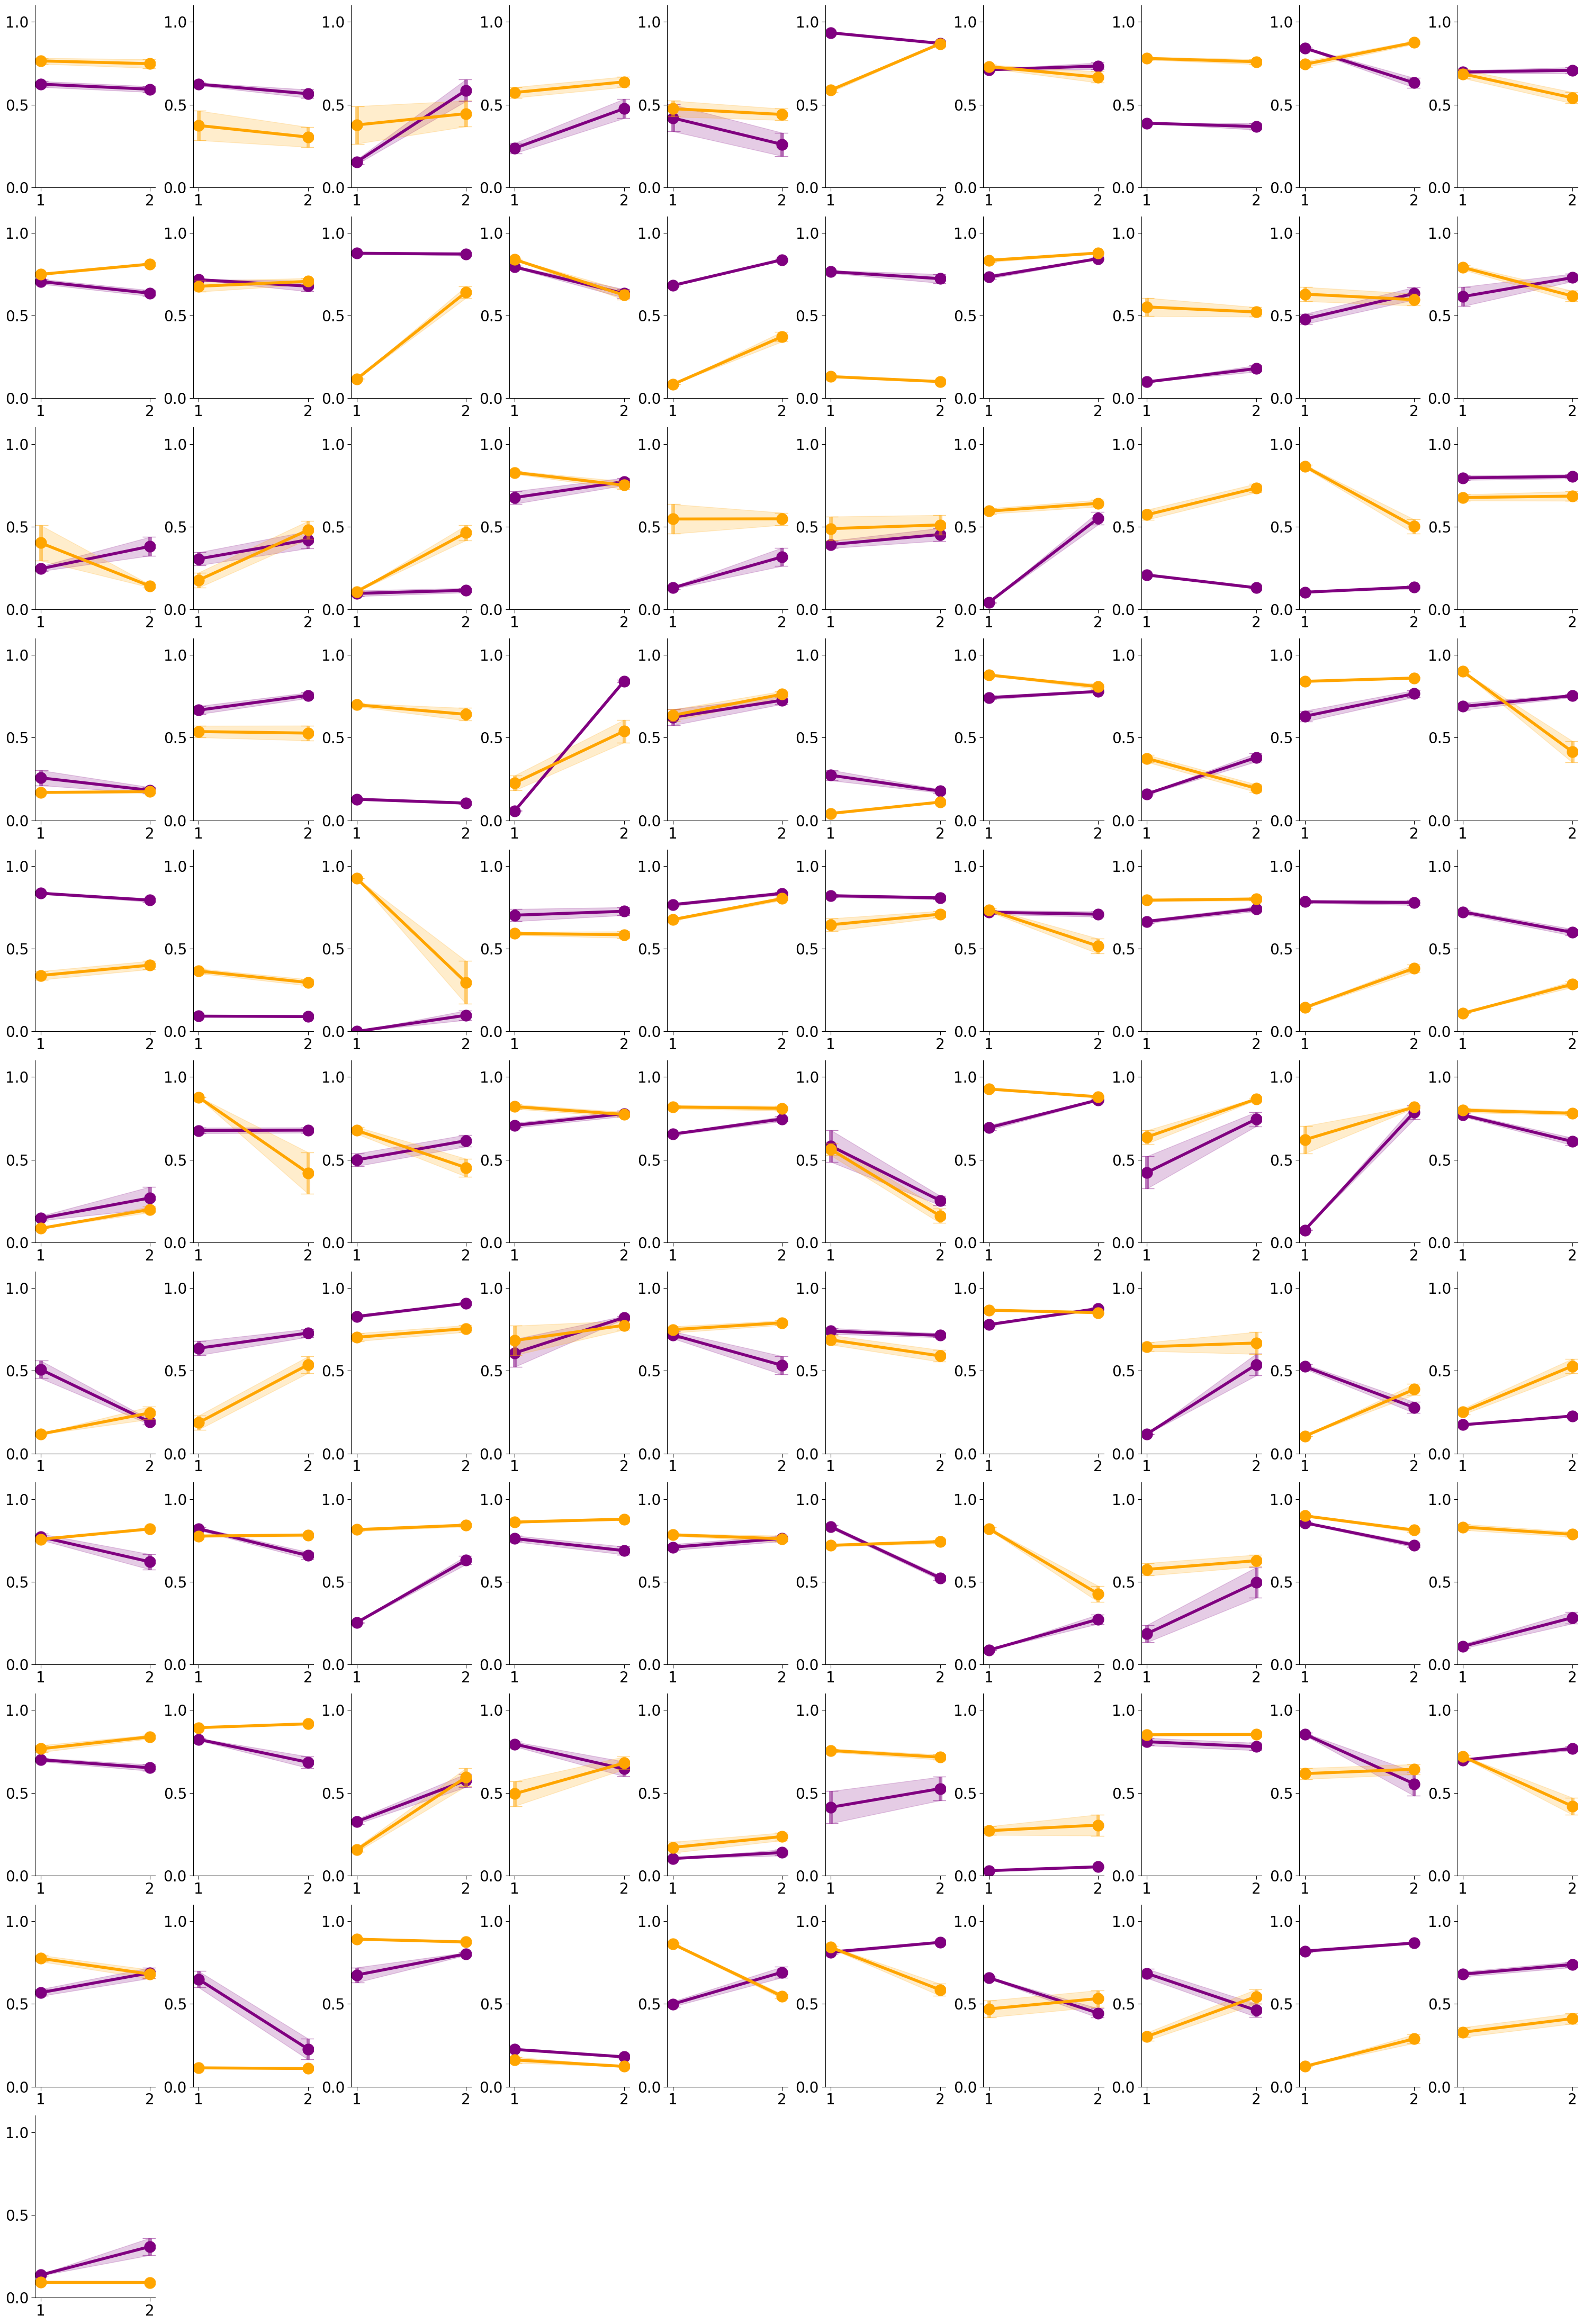

In [370]:
fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3 * n_cols, 4 * n_rows)
)

# Make axs always 2D
axs = np.atleast_2d(axs)

for i in range(n_plots):

    row = i // n_cols
    col = i % n_cols

    ax = axs[row, col]

    for j in range(2):

        pseudonym = pseudo_tuples_list[i][j]

        first_solo = occupancy_dict['first_solos']['final_20_pct']['mean'][pseudonym]
        social = occupancy_dict['socials']['first_10_pct']['mean'][pseudonym]

        first_variance = np.var(occupancy_dict['first_solos']['final_20_pct']['values'][pseudonym])
        social_variance = np.var(occupancy_dict['socials']['first_10_pct']['values'][pseudonym])

        color = 'purple' if j == 0 else 'orange'

        ax.plot(
            [1,2],
            [first_solo, social],
            marker='o',
            markersize=15,
            linestyle='-',
            linewidth=4,
            color=color,
            alpha=1
        )

        # add variance as shaded area around the line
        ax.fill_between(
            [1,2],
            [first_solo - first_variance, social - social_variance],
            [first_solo + first_variance, social + social_variance],
            color=color,
            alpha=0.2
        )

        # add error bars with top and bottom caps
        ax.errorbar(
            [1,2],
            [first_solo, social],
            yerr=[first_variance, social_variance],
            fmt='none',
            ecolor=color,
            elinewidth=5,
            alpha=0.5,
            capsize=10
        )

    ax.set_ylim(0, 1.1)
    ax.set_yticks(np.arange(0, 1.1, 0.5))
    ax.tick_params(length=5, labelsize=20)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
total_axes = n_rows * n_cols

for k in range(n_plots, total_axes):

    row = k // n_cols
    col = k % n_cols

    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

In [371]:
# Could classify as shifting toward/away/with opponent
# Could classify as shift or no shift and replicate above matrices

In [380]:
def shift_no_shift(first_solo, social, cutoff=0.2):
    first_solo = np.array(first_solo)
    social = np.array(social)

    first_mean = np.nanmean(first_solo)
    social_mean = np.nanmean(social)

    g = social_mean - first_mean

    if abs(g) < cutoff:
        return 'NO ADAPT'
    if abs(g) >= cutoff:
        return 'ADAPT'

In [393]:
def classify_dyad(g_player, g_opp, cutoff=0.2):

    if abs(g_player) < cutoff and abs(g_opp) < cutoff:
        return 'stable'

    elif abs(g_player) >= cutoff and abs(g_opp) < cutoff:
        if np.sign(g_player) == -np.sign(g_opp):
            return 'opposite dir stable opp'
        elif np.sign(g_player) == np.sign(g_opp):
            return 'same dir stable opp'

    elif abs(g_opp) >= cutoff and abs(g_player) < cutoff:
        if np.sign(g_opp) == -np.sign(g_player):
            return 'opposite dir stable plyr'
        elif np.sign(g_opp) == np.sign(g_player):
            return 'same dir stable plyr'

    elif abs(g_player) >= cutoff and abs(g_opp) >= cutoff:
        if np.sign(g_player) == -np.sign(g_opp):
            return 'opposite dir'
        elif np.sign(g_player) == np.sign(g_opp):
            return 'same dir'

In [394]:
shifts = []
dyad_classes = []

for i in range(len(pseudo_tuples_list)):

    player = pseudo_tuples_list[i][0]
    opp = pseudo_tuples_list[i][1]

    first_solo_ply = np.array(occupancy_dict['first_solos']['final_20_pct']['mean'][player])
    social_ply = np.array(occupancy_dict['socials']['first_10_pct']['mean'][player])
    
    first_solo_opp = np.array(occupancy_dict['first_solos']['final_20_pct']['mean'][opp])
    social_opp = np.array(occupancy_dict['socials']['first_10_pct']['mean'][opp])

    g_player = social_ply - first_solo_ply
    g_opp = social_opp - first_solo_opp

    dyad_shift_class = classify_dyad(g_player, g_opp)

    print(dyad_shift_class)

    trait_df.loc[player, 'dyad_shift_class'] = dyad_shift_class
    trait_df.loc[opp, 'dyad_shift_class'] = dyad_shift_class 

    for j in range(2):

        pseudonym = pseudo_tuples_list[i][j]

        first_solo = np.array(occupancy_dict['first_solos']['final_20_pct']['values'][pseudonym])
        social = np.array(occupancy_dict['socials']['first_10_pct']['values'][pseudonym])

        shift_pseudo = shift_no_shift(first_solo, social)
        shifts.append(shift_pseudo)

        trait_df.loc[pseudonym, 'fast_shift_class'] = shift_pseudo


stable
stable
same dir stable opp
same dir stable opp
stable
opposite dir stable plyr
stable
stable
opposite dir stable opp
stable
stable
stable
opposite dir stable plyr
same dir stable plyr
same dir stable plyr
stable
stable
stable
stable
stable
opposite dir stable plyr
same dir stable plyr
same dir stable plyr
stable
stable
stable
same dir stable opp
stable
opposite dir stable plyr
stable
stable
stable
stable
same dir
stable
stable
stable
opposite dir stable opp
stable
opposite dir stable plyr
stable
stable
opposite dir stable plyr
stable
stable
stable
same dir stable plyr
stable
opposite dir stable plyr
stable
stable
opposite dir stable plyr
opposite dir stable plyr
stable
stable
same dir
stable
same dir
same dir stable opp
stable
opposite dir stable opp
same dir stable plyr
stable
same dir stable opp
stable
stable
stable
same dir stable opp
opposite dir
same dir stable plyr
stable
stable
same dir stable opp
stable
stable
opposite dir stable opp
opposite dir stable plyr
same dir sta

### Pie chart for adaptation categories

([<matplotlib.patches.Wedge at 0x31e0b6ad0>,
 [Text(-0.8338745085402242, 0.7476986719306112, 'NO ADAPT'),
  Text(0.8338745739061175, -0.7476985990309807, 'ADAPT')],
 [Text(-0.5211715678376401, 0.4673116699566319, '76.7%'),
  Text(0.5211716086913234, -0.4673116243943628, '23.3%')])

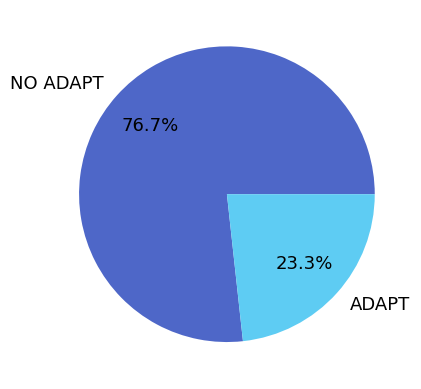

In [397]:
# fractions of different EARLY adaptation categories
early_shift_class = trait_df['fast_shift_class'].tolist()

from collections import Counter
items = list(Counter(early_shift_class).keys())
counts = list(Counter(early_shift_class).values())

df = pd.DataFrame(
    {"counts": [98, 104]},
    index=['NO ADAPT', 'ADAPT'],
)

fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

### Confusion matrix for dyads

In [402]:
opponents = list(trait_df['opponent'])

In [410]:
early_shift_class_player = early_shift_class

In [412]:
early_shift_class_opponent = []

for i, opponent in enumerate(opponents):
    early_shift_class = trait_df['fast_shift_class'][opponent]
    early_shift_class_opponent.append(early_shift_class)

trait_df['early_shift_class_opponent'] = early_shift_class_opponent

In [415]:
# Importing LabelEncoder from Sklearn 
# library from preprocessing Module.
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()

# Using .fit_transform function to fit label
# encoder and return encoded label

early_player_labels = le.fit_transform(early_shift_class_player)
early_opponent_labels = le.fit_transform(early_shift_class_opponent)

In [417]:
# confusion matrices

# 1. likelihood of pairings

In [416]:
# create list of player-opponent pairs
#dyads = list(zip(player_labels, opponent_labels))
early_dyads = list(zip(early_shift_class_player, early_shift_class_opponent))

early_count = Counter(early_dyads)

sorted_early_counts = sorted(early_count.items(), key=lambda tup: (tup[0][1], tup[0][0]))

types_of_early_dyads = [dyad for dyad, freq in sorted_early_counts]
frequency_of_early_dyads = [freq for dyad, freq in sorted_early_counts]

In [418]:
cmap = load_cmap("Mint")

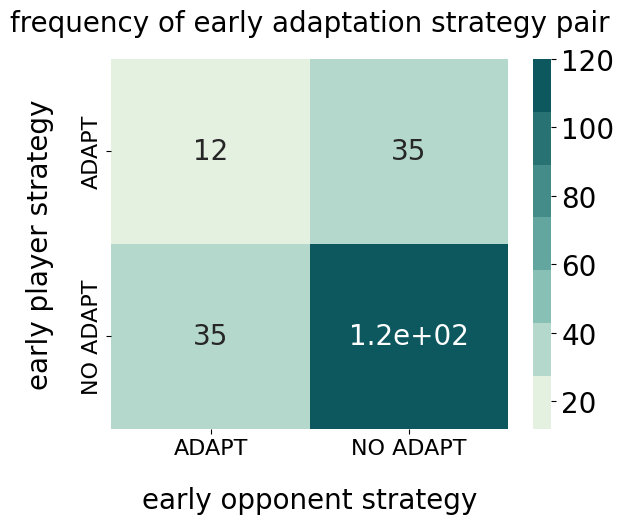

In [422]:
cm = pd.DataFrame(
    0,
    index=sorted(set(early_shift_class_player)),
    columns=sorted(set(early_shift_class_opponent))
)

for (player,opponent), freq in early_count.items():
    cm.loc[player, opponent] = freq

sns.heatmap(cm, annot=True, cmap=cmap, annot_kws={"size":20})

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("frequency of early adaptation strategy pair", fontsize=20, pad=20)
plt.xlabel('early opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('early player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

In [424]:
# confusion matrices

# 2. proportion scores

In [423]:
proportion_scores = list(trait_df['proportion_score'])

In [427]:
heatmap_data = pd.pivot_table(
    trait_df,
    values='proportion_score',
    index='fast_shift_class',
    columns='early_shift_class_opponent',
    aggfunc='mean'
)

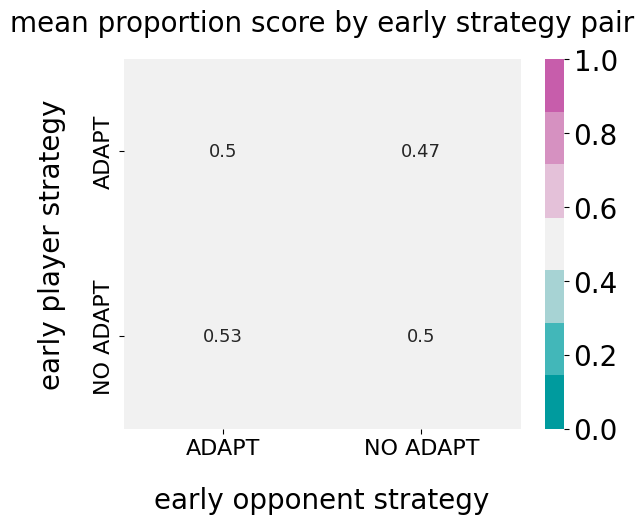

In [428]:
cmap = load_cmap("Tropic")

# cell values
# 0.5: equal performance
# 0.6 and above: row strategy typically gets 60+% of points against column strategy
# 0.4 and below: column strategy typically gets 60+% of points against column strategy

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1, 
    annot_kws={"size":13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean proportion score by early strategy pair", fontsize=20, pad=20)
plt.xlabel('early opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('early player strategy',  fontsize=20, labelpad=20)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

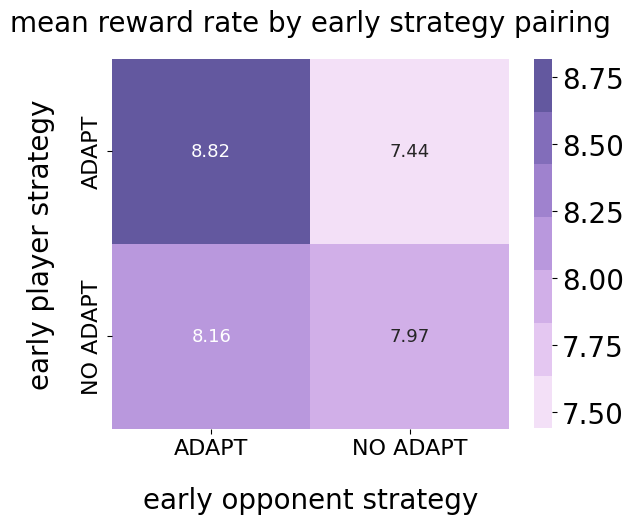

In [429]:
scores_per_second_matrix = pd.pivot_table(
    trait_df,
    values='scores_per_unit_time_socials',
    index='fast_shift_class',
    columns='early_shift_class_opponent',
    aggfunc='mean'
)

cmap = load_cmap("Purp")

sns.heatmap(
    scores_per_second_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    annot_kws={"size": 13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean reward rate by early strategy pairing", fontsize=20, pad=20)
plt.xlabel('early opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('early player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

# cells: when row strategy meets column strategy, the former gets X points/s average

## Switch in social

### Average centrality slope across social for level of reactive switch

### Variance around the mean with sliding window for precision of players in their strategy

(calculate mean for a small window and variance around it then average across windows???)

## Score

### Does proportion score increase as players are rated from 'least confident understanding' to 'most confident understanding'

## Dyads

### Separate lower scoring platers into 'adapting' and 'resigning'. Proportion score should even out over time for players who adapt